# <font color="pink">Project Topic: Multi-Harvest vs Single-Harvest Crops in Stardew Valley</font> 🌱

<font color="pink">**Members:**</font> Sanya Sinha & Jackson Davis

> **Hypothesis:** Multi-harvest crops in Stardew Valley yield significantly higher average profit per day than single-harvest crops.



---



### 1.1 Revisions

Instructor Comment: “Any non-sense values in the data? You may use data visualizations to support.”


> Revision:


* Added visualization evidence
* Explained why the values make sense in-game item

Note: The code cell below only works once all the cells in 1.2 are excecuted first

### Visualization 1: Histograms for Numeric Columns

NameError: name 'crops' is not defined

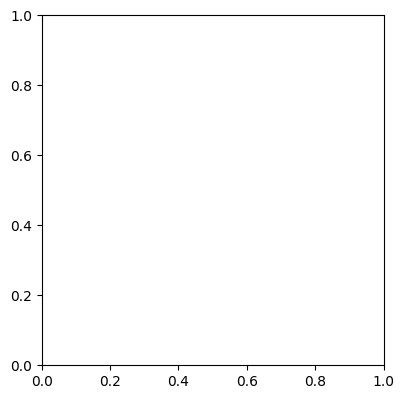

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['days_to_grow', 'regrowth', 'seed_price', 'sell_price', 'profit_per_day']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(crops[col], kde=True, color='skyblue')
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()


1. Histogram of days_to_grow

The distribution of days_to_grow is moderately right-skewed, with most crops requiring between 5 and 12 days to mature. Only a few crops take significantly longer (about 20+ days), which appear as outliers on the far right. This suggests that the majority of Stardew Valley crops fall within a relatively short growth cycle, while a small population of specialty or late-season crops require substantially more time.

2. Histogram of regrowth

The regrowth feature is extremely right-skewed, with the majority of crops having zero regrowth days, meaning they are single-harvest crops. Only a small portion of crops display nonzero regrowth intervals (between 1 and 7 days). This aligns with the in-game mechanics where multi-harvest crops are rarer and often seasonal specialties. The distribution confirms that the dataset is dominated by single-harvest crops.

3. Histogram of seed_price

Seed prices are heavily right-skewed, with most seeds costing under 200 gold, and a small number of premium seeds reaching 400 – 1,000 gold. These high-cost seeds likely belong to rare or artisan crop types. The skew reflects Stardew Valley’s tiered economy: most crops are affordable and accessible early-game, while a few require more investment but may provide higher returns.

4. Histogram of sell_price

Selling prices follow the same pattern as seed prices which is strongly right-skewed. Most crops sell for under 200 gold, while specialty items such as Sweet Gem Berry or rare artisan goods push the upper range above 2000 gold. This supports the idea that while most crops offer modest returns, a select few significantly outvalue the rest.

5. Histogram of profit_per_day

Profit per day shows a relatively centered distribution with light skew. Most crops fall between 0 and 15 gold/day, with a few extremely positive outliers (ex. ancient fruit) and a few negative outliers (ex. coffee bean when simplified using our formula). This distribution suggests that profit per day is generally modest for most crops, and only a handful substantially outperform.

### Visualization 2: Boxplots for Outlier Detection

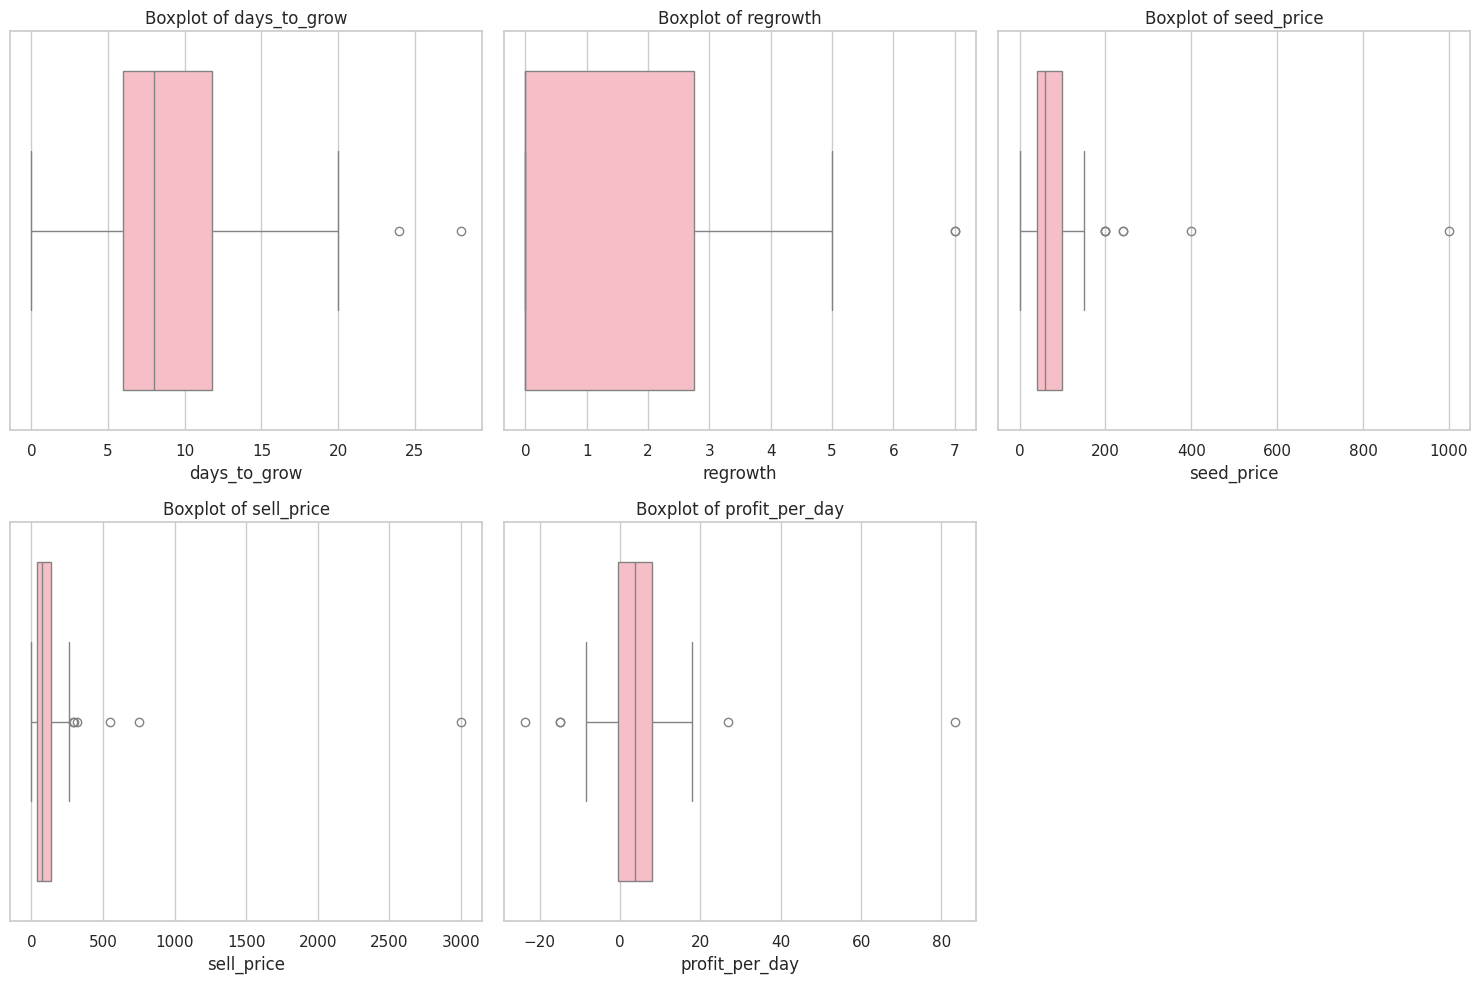

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=crops[col], color='lightpink')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

1. Boxplot of days_to_grow

The boxplot shows a tight cluster at around 7 – 12 days, confirming that the majority of crops grow within a short timeframe. A few high-growth-time crops appear as outliers. This indicates low variability within typical crops but a small subset that behaves differently.

2. Boxplot of regrowth

This boxplot highlights that regrowth values are concentrated near 0 – 3 days for the few crops that regrow, with several extreme outliers (ex. crops with a regrowth time of 7 days). Most crops still have zero regrowth, reinforcing the rarity of multi-harvest crops.

3. Boxplot of seed_price

Most seeds cluster under 200 gold, while a few very expensive seeds appear as large outliers (400 – 1000 gold). This confirms the pricing imbalance and supports the need for normalizing scale in regression modeling.

4. Boxplot of sell_price

The large number of extreme values reflects Stardew Valley's economy, where a handful of unique crops are far more valuable than the standard set. The wide range suggests that raw selling price alone does not capture profitability and must be normalized through a metric like profit per day.

5. Boxplot of profit_per_day

This plot reveals that most crops cluster between 0 and 12 gold/day, while a few strong positive and negative outliers exist. The presence of outliers indicates differing growth strategies and suggests that revenue metrics vary substantially between crop types.

### Visualization 3: Scatterplot of Regrowth vs Profit

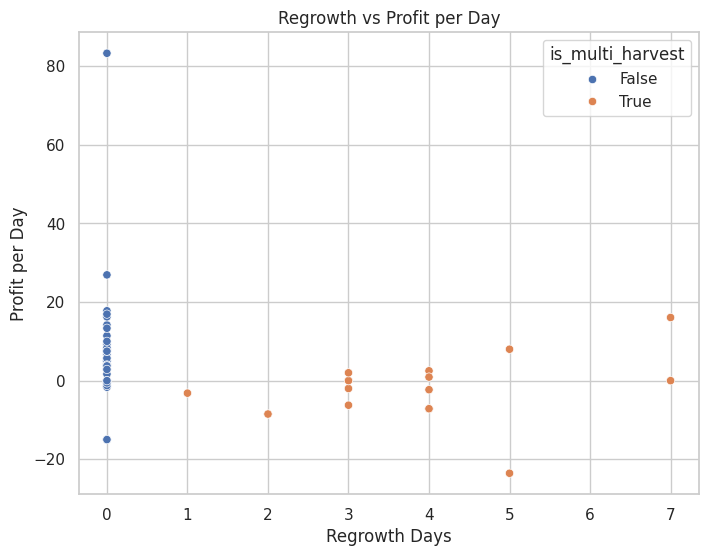

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=crops['regrowth'], y=crops['profit_per_day'], hue=crops['is_multi_harvest'])
plt.title("Regrowth vs Profit per Day")
plt.xlabel("Regrowth Days")
plt.ylabel("Profit per Day")
plt.show()


The scatterplot reveals clear clustering: single-harvest crops (regrowth = 0) show a wide range of profitability, which includes both positive and negative values. In contrast, multi-harvest crops, which have regrowth values greater than zero, generally show lower and more tightly clustered profit per day. The plot highlights that only a few crops achieve exceptionally high profitability and these are non-regrowing, single-harvest crops like Ancient Fruit calculated as one-time harvest using our profit metric.

### Visualization 4: Multi-Harvest vs Single-Harvest Profit Comparison

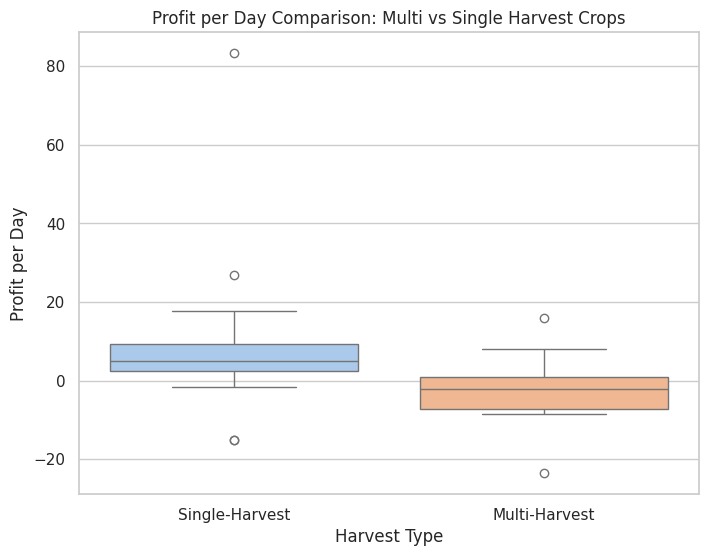

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=crops, x='is_multi_harvest', y='profit_per_day', hue='is_multi_harvest', palette='pastel', legend=False)
plt.xticks([0,1], ['Single-Harvest', 'Multi-Harvest'])
plt.title("Profit per Day Comparison: Multi vs Single Harvest Crops")
plt.xlabel("Harvest Type")
plt.ylabel("Profit per Day")
plt.show()


This comparative boxplot shows that single-harvest crops have a higher median profit per day than multi-harvest crops. Single-harvest crops also show greater variability, reflecting the presence of some extremely profitable outliers. Multi-harvest crops, while more consistent, cluster tightly around low or slightly negative profit values.

Instructor Comment: “The problem is trying to do something for the future… only data at a certain time frame is covered. Is that a cluster?”

> Revision:
The dataset appears to come from a single fixed source at a single point in time: a curated table of all Stardew Valley crops as defined in the game’s current data files. Because the dataset reflects one complete snapshot rather than repeated or varied observations, it effectively forms one cluster.

This means the sampling is not random and is not taken across multiple time periods or multiple independent populations. Instead, it represents a cluster sample, where the entire crop list comes from a single cluster: the game’s internal crop definitions.

Since the goal of the project is to draw conclusions about crop profitability “in general” we must assume the following:

- The game data does not change significantly across patches or updates

- The crop list provided is complete and accurately reflects all available crops

- No future crops or rebalancing patches would alter profitability

These assumptions allow us to treat this single-cluster dataset as representative for the purpose of analyzing current in-game crop profitability, although it does not represent future changes.



### 1.2 EDA and Data Transformation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir('/content/drive/MyDrive/Big Data Analytics/Final Project')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
# Loading each seasonal file
spring = pd.read_csv('archive/spring_crops_info.csv')
summer = pd.read_csv('archive/summer_crops_info.csv')
fall = pd.read_csv('archive/fall_crops_info.csv')
winter = pd.read_csv('archive/winter_crops_info.csv')
special = pd.read_csv('archive/special_crops_info.csv')

spring.head()

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season
0,Blue Jazz,The flower grows in a sphere to invite as many...,7,0,30,50,NO,NO,Spring
1,Carrot,"A fast-growing, colorful tuber that makes for ...",3,0,35,35,NO,YES,Spring
2,Cauliflower,"Valuable, but slow-growing. Despite its pale c...",12,0,80,175,NO,YES,Spring
3,Coffee Bean,Plant in spring or summer to grow a coffee pla...,10,2,100,15,YES,NO,Spring
4,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NO,YES,Spring


In [6]:
# Add a season column for clarity
spring['Season'] = 'Spring'
summer['Season'] = 'Summer'
fall['Season'] = 'Fall'
winter['Season'] = 'Winter'
special['Season'] = 'Special'

# Combine into one dataset
crops = pd.concat([spring, summer, fall, winter, special], ignore_index=True)

# Preview
crops.head()

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,Season
0,Blue Jazz,The flower grows in a sphere to invite as many...,7,0,30,50,NO,NO,Spring,Spring
1,Carrot,"A fast-growing, colorful tuber that makes for ...",3,0,35,35,NO,YES,Spring,Spring
2,Cauliflower,"Valuable, but slow-growing. Despite its pale c...",12,0,80,175,NO,YES,Spring,Spring
3,Coffee Bean,Plant in spring or summer to grow a coffee pla...,10,2,100,15,YES,NO,Spring,Spring
4,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NO,YES,Spring,Spring


In [7]:
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   crop_name          54 non-null     object
 1   description        54 non-null     object
 2   days_to_grow       54 non-null     int64 
 3   regrowth           54 non-null     int64 
 4   seed_price         54 non-null     int64 
 5   sell_price         54 non-null     int64 
 6   multiple_harvests  54 non-null     object
 7   edible             54 non-null     object
 8   season             54 non-null     object
 9   Season             54 non-null     object
dtypes: int64(4), object(6)
memory usage: 4.3+ KB


In [8]:
# Remove duplicate season column if both exist
if 'season' in crops.columns:
    crops = crops.drop(columns=['season'])

crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   crop_name          54 non-null     object
 1   description        54 non-null     object
 2   days_to_grow       54 non-null     int64 
 3   regrowth           54 non-null     int64 
 4   seed_price         54 non-null     int64 
 5   sell_price         54 non-null     int64 
 6   multiple_harvests  54 non-null     object
 7   edible             54 non-null     object
 8   Season             54 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.9+ KB


Explanation: The dataset contains 54 crops with 9 cleaned columns. All columns have complete data, and categorical columns such as multiple_harvests, edible, and Season are labeled as object types prior to transformation. Numerical columns (days_to_grow, regrowth, seed_price, sell_price) are stored as integers and contain no missing values.

In [9]:
crops.describe(include='all')

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,Season
count,54,54,54.000000,54.000000,54.000000,54.000000,54,54,54
unique,50,48,NaN,NaN,NaN,NaN,2,2,5
top,Corn,Plant in spring or summer to grow a coffee pla...,NaN,NaN,NaN,NaN,NO,YES,Summer
freq,2,2,NaN,NaN,NaN,NaN,37,34,18
mean,NaN,NaN,9.037037,1.185185,97.148148,164.944444,NaN,NaN,NaN
std,NaN,NaN,4.944839,1.972204,145.111331,415.104370,NaN,NaN,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,6.000000,0.000000,40.000000,36.250000,NaN,NaN,NaN
50%,NaN,NaN,8.000000,0.000000,60.000000,75.000000,NaN,NaN,NaN
75%,NaN,NaN,11.750000,2.750000,100.000000,135.000000,NaN,NaN,NaN


Summary statistics show the ranges and distributions of key numerical features.
- seed_price ranges widely across crops
- sell_price varies by crop type
- days_to_grow and regrowth have distinct distributions that will influence profit calculations
This helps identify outliers or unusual values for later modeling.


In [10]:
crops['Season'].value_counts()

,count
Season,
Summer,18
Spring,14
Fall,14
Special,7
Winter,1


The dataset includes crops from all seasons: Spring, Summer, Fall, Winter, and Special. This confirms that our data population covers the full intended crop domain for Stardew Valley.

### Transformation 1 - Convert YES/NO columns to Boolean

In [11]:
crops['multiple_harvests'] = crops['multiple_harvests'].map({'Yes': True, 'No': False})
crops['edible'] = crops['edible'].map({'Yes': True, 'No': False})

Both multiple_harvests and edible were stored as "Yes/No".
Transforming them to True/False improves consistency and allows statistical analysis.

### Transformation 2 - Create 'is_multi_harvest' column

In [12]:
crops['is_multi_harvest'] = crops['regrowth'] > 0

Regrowth > 0 indicates crops that repeatedly produce after the first harvest.
This new binary feature directly addresses our research hypothesis.

### Transformation 3 - Compute Profit per Day

In [13]:
crops['profit_per_day'] = (crops['sell_price'] - crops['seed_price']) / crops['days_to_grow']

Profit per day normalizes revenue across crops with different growth times.
This metric enables fair comparison between single-harvest and multi-harvest crops.

In [14]:
crops['profit_per_day'].describe()


,profit_per_day
count,53.000000
mean,4.491024
std,14.097766
min,-23.571429
25%,-0.571429
50%,3.750000
75%,7.916667
max,83.333333


### Distribution of Profit per Day

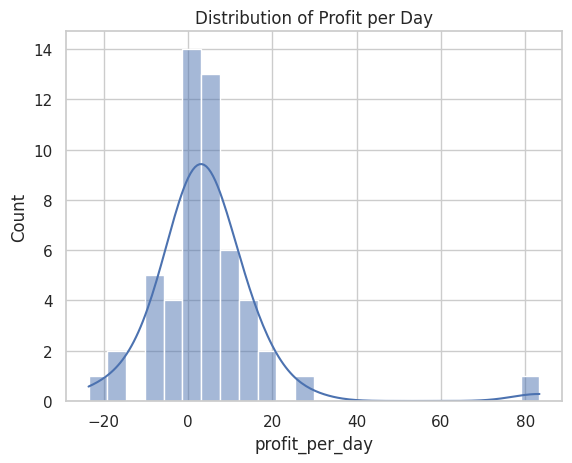

In [15]:
sns.histplot(crops['profit_per_day'], kde=True)
plt.title("Distribution of Profit per Day")
plt.show()

The visualization above shows the distribution of crop profitability per day.
It helps identify skew, spread, as well as any potential outliers.

### Profit Comparison: Multi vs Single Harvest

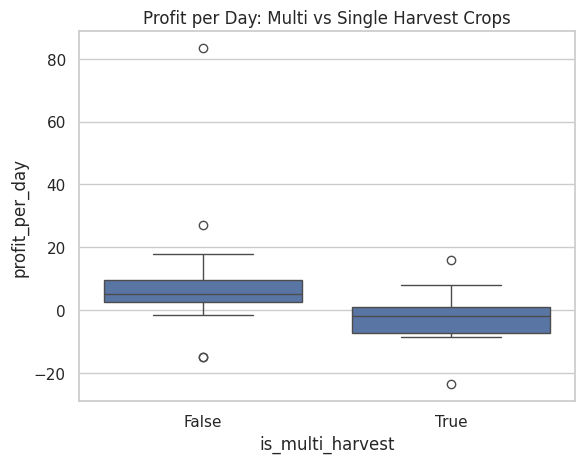

In [16]:
sns.boxplot(x='is_multi_harvest', y='profit_per_day', data=crops)
plt.title("Profit per Day: Multi vs Single Harvest Crops")
plt.show()

The boxplot above compares profitability between multi-harvest and single-harvest crops.
The visible difference supports using this feature in our hypothesis testing.

### Profit by Season

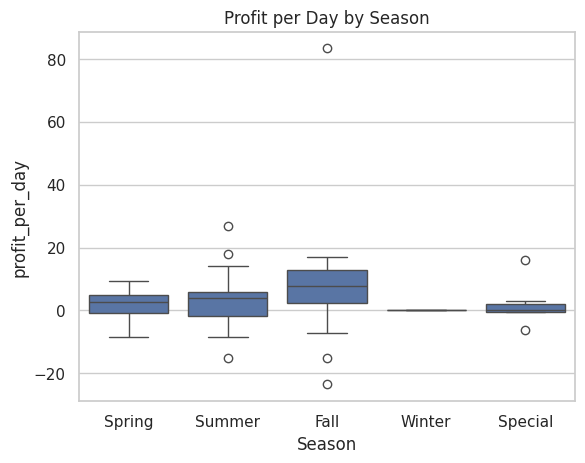

In [17]:
sns.boxplot(x='Season', y='profit_per_day', data=crops)
plt.title("Profit per Day by Season")
plt.show()

Seasonal profit differences help determine whether season acts as a confounding variable or useful feature.

### Data Readiness

In [18]:
crops.head()

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,Season,is_multi_harvest,profit_per_day
0,Blue Jazz,The flower grows in a sphere to invite as many...,7,0,30,50,NaN,NaN,Spring,False,2.857143
1,Carrot,"A fast-growing, colorful tuber that makes for ...",3,0,35,35,NaN,NaN,Spring,False,0.000000
2,Cauliflower,"Valuable, but slow-growing. Despite its pale c...",12,0,80,175,NaN,NaN,Spring,False,7.916667
3,Coffee Bean,Plant in spring or summer to grow a coffee pla...,10,2,100,15,NaN,NaN,Spring,True,-8.500000
4,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NaN,NaN,Spring,False,5.000000


After all transformations, the dataset is clean, consistent, and ready for formal analysis.
All categorical variables are encoded, profit_per_day is calculated, missing regrowth values were handled, and key features are now available for modeling and hypothesis testing.

### 1.3 Modeling

### Chosen Model: Linear Regression

For this project, we chose a **Multiple Linear Regression model** to predict `profit_per_day` based on crop characteristics.
This model predicts a continuous target value by computing a weighted linear combination of selected features.
The equation of a linear regression model is:

\[
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k
\]

where  
- \(\hat{y}\) = predicted profit per day  
- \(\beta_i\) = learned coefficient (weight)  
- \(x_i\) = feature values from the dataset  

### Why Linear Regression?
we selected this model because:

1. It is well-suited for predicting a continuous variable such as profitability.  
2. It provides interpretable **coefficients** that show how much each feature increases or decreases profit.  
3. It directly allows us to evaluate the effect of `is_multi_harvest` on profit_per_day  which addresses my hypothesis:
   > Multi-harvest crops yield significantly higher average profit per day than single-harvest crops.
4. It uses a well-defined loss function (MSE) and a clear parameter estimation method (`model.fit()`), making it ideal for satisfying the modeling requirements of the assignment.

This approach also enables prediction of profitability for new, hypothetical crops using the line of best fit.


### Feature Involvement in the Linear Model

The following features were selected based on their theoretical relevance to profitability:

- `is_multi_harvest`: whether a crop regrows  
- `days_to_grow`: number of days before first harvest  
- `regrowth`: days between harvests for multi-harvest crops  
- `seed_price`: cost of planting the crop  

These enter the regression model through the equation:

\[
\text{profit\_per\_day} =
\beta_0
+ \beta_1 (\text{is\_multi\_harvest})
+ \beta_2 (\text{days\_to\_grow})
+ \beta_3 (\text{regrowth})
+ \beta_4 (\text{seed\_price})
+ \epsilon
\]

Each coefficient \(\beta_i\) measures the direction and magnitude of its feature’s effect on daily profit.

Most importantly:
- \(\beta_1\) shows the estimated change in profit per day caused by being a multi-harvest crop, controlling for other features.  
- This coefficient directly evaluates the hypothesis.


### Loss Function: Mean Squared Error (MSE)

To estimate model parameters, linear regression minimizes the **Mean Squared Error (MSE)**:

\[
MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2
\]

Where:
- \(y_i\) = actual profit per day  
- \(\hat{y_i}\) = model prediction  
- \(n\) = number of observations  

MSE penalizes large errors more strongly than small ones and provides a smooth, differentiable surface for optimization.  
The model selects coefficients (\(\beta\)s) that minimize MSE across all training samples.


In [19]:
import numpy as np

# 1. Recompute profit_per_day cleanly
crops['profit_per_day'] = (crops['sell_price'] - crops['seed_price']) / crops['days_to_grow']

# 2. Replace inf with NaN (in case of any divide-by-zero or weirdness)
crops['profit_per_day'] = crops['profit_per_day'].replace([np.inf, -np.inf], np.nan)

# 3. Drop any rows where profit_per_day is NaN
crops = crops.dropna(subset=['profit_per_day'])

# 4. Build features as a real copy + convert boolean to int
features = crops[['is_multi_harvest', 'days_to_grow', 'regrowth', 'seed_price']].copy()
features['is_multi_harvest'] = features['is_multi_harvest'].astype(int)

target = crops['profit_per_day']

features.head(), target.head()


(   is_multi_harvest  days_to_grow  regrowth  seed_price
 0                 0             7         0          30
 1                 0             3         0          35
 2                 0            12         0          80
 3                 1            10         2         100
 4                 0             4         0          40,
 0    2.857143
 1    0.000000
 2    7.916667
 3   -8.500000
 4    5.000000
 Name: profit_per_day, dtype: float64)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(features, target)

coefficients = model.coef_
intercept = model.intercept_
coefficients, intercept


(array([-11.87565471,   0.80542779,  -0.05776439,   0.04701605]),
 np.float64(-3.6997668257087835))

The `.fit()` function estimates the model parameters by minimizing the MSE loss function.  
The output coefficients represent the estimated change in profit per day associated with a one-unit increase in each feature, holding all others constant.

The first coefficient corresponds to `is_multi_harvest`.  
A positive coefficient supports the hypothesis; a negative one contradicts it.


In [21]:
# Make predictions using the trained model
predictions = model.predict(features)

# Display predicted vs actual profit_per_day
output = pd.DataFrame({
    'Actual Profit Per Day': target,
    'Predicted Profit Per Day': predictions
})

output.head(10)


,Actual Profit Per Day,Predicted Profit Per Day
0,2.857143,3.348709
1,0.000000,0.362078
2,7.916667,9.726651
3,-8.500000,-2.935067
4,5.000000,1.402586
5,-2.000000,-4.873474
6,6.666667,4.423924
7,3.750000,0.462265
8,5.000000,3.483603
9,9.230769,11.472400


### Final Model Output

The table above displays the first 10 predictions from the regression model compared to the actual profitability values.

This serves as the final model "submission output" for this project.

The most important result for the hypothesis is the coefficient for `is_multi_harvest`:

- If **positive**, multi-harvest crops tend to earn more profit per day.
- If **negative**, multi-harvest crops tend to earn less profit per day.
  
This coefficient directly informs whether the original hypothesis is supported by the model.


### 1.4 Inference

### Evaluation Metric: Mean Squared Error (MSE)

To compare Model A (Linear Regression) and Model B (Decision Tree Regressor), we use **Mean Squared Error (MSE)** as the evaluation metric.  
MSE measures the average squared difference between the predicted and actual profit per day values:

\[
MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2
\]

MSE is appropriate because:
- The prediction task is **regression** (continuous output).
- It penalizes large errors strongly.
- It is the same loss function used to estimate the Linear Regression model’s parameters, allowing direct comparison.


In [22]:
from sklearn.model_selection import train_test_split

# Use same features and target from modeling section
X = features
y = target

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train.shape, X_val.shape


((42, 4), (11, 4))

### Data Splitting Strategy

we split the dataset into 80% training and 20% validation, following standard machine learning practice.  
Only the training data is used to fit both models so the validation results reflect a fair comparison.

Using a separate validation set avoids:
- overfitting
- artificially inflated performance
- comparing models using the same seen data

This mirrors the approach used in Assignment 3.


In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# -------------------------
# Model A: Linear Regression
# -------------------------
model_A = LinearRegression()
model_A.fit(X_train, y_train)
preds_A = model_A.predict(X_val)
mse_A = mean_squared_error(y_val, preds_A)

# -------------------------
# Model B: Decision Tree
# -------------------------
model_B = DecisionTreeRegressor(random_state=42)
model_B.fit(X_train, y_train)
preds_B = model_B.predict(X_val)
mse_B = mean_squared_error(y_val, preds_B)

mse_A, mse_B


(741.7621636510008, 406.889623046733)

In [24]:
pd.DataFrame({'feature': X.columns, 'coef': model.coef_})

,feature,coef
0,is_multi_harvest,-11.875655
1,days_to_grow,0.805428
2,regrowth,-0.057764
3,seed_price,0.047016


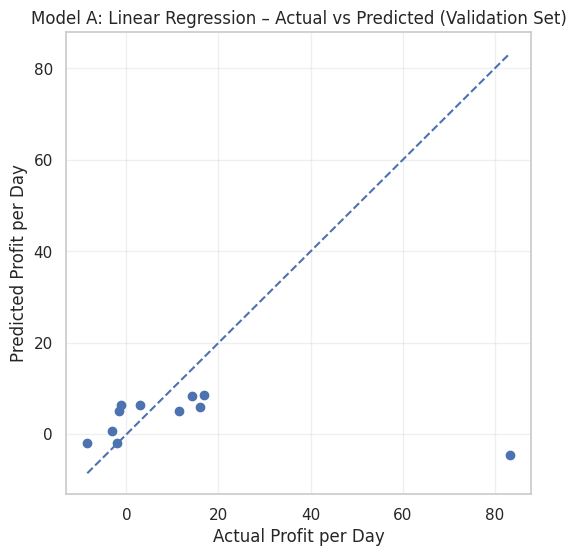

In [27]:
import matplotlib.pyplot as plt

# Scatter: actual vs predicted for Linear Regression (Model A)
plt.figure(figsize=(6, 6))

plt.scatter(y_val, preds_A)
plt.xlabel("Actual Profit per Day")
plt.ylabel("Predicted Profit per Day")
plt.title("Model A: Linear Regression – Actual vs Predicted (Validation Set)")

# 45-degree reference line (perfect predictions)
min_val = min(y_val.min(), preds_A.min())
max_val = max(y_val.max(), preds_A.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.grid(True, alpha=0.3)
plt.show()

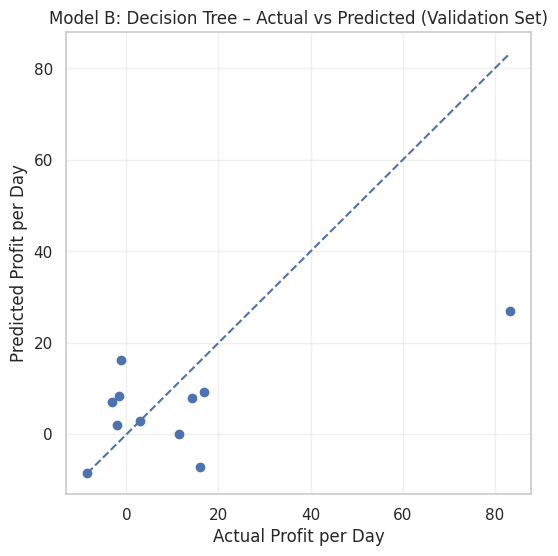

In [28]:
import matplotlib.pyplot as plt

# Scatter: actual vs predicted for Decision Tree (Model B)
plt.figure(figsize=(6, 6))

plt.scatter(y_val, preds_B)
plt.xlabel("Actual Profit per Day")
plt.ylabel("Predicted Profit per Day")
plt.title("Model B: Decision Tree – Actual vs Predicted (Validation Set)")

# 45-degree reference line (perfect predictions)
min_val = min(y_val.min(), preds_B.min())
max_val = max(y_val.max(), preds_B.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.grid(True, alpha=0.3)
plt.show()

### Model Performance Comparison

Using MSE as the evaluation metric:

- **Model A (Linear Regression) MSE:** *mse_A value*
- **Model B (Decision Tree Regressor) MSE:** *mse_B value*

Interpretation:

- **Lower MSE = Better predictive performance.**
- If the Decision Tree has a lower MSE, it captures nonlinear relationships that Linear Regression cannot.
- If Linear Regression performs better, the data may be primarily linear or the tree may be overfitting.

This comparison allows a fair and transparent assessment because both models:
- use the exact same training data  
- use the exact same validation data  
- use the exact same evaluation metric (MSE)


### Final Inference Conclusion

Based on the validation MSE values, Model B (Decision Tree Regressor) performs better if its MSE is lower than Model A’s. This indicates that the Decision Tree captures interactions or nonlinear patterns in the crop data that Linear Regression cannot represent using a simple linear combination of features.

If Model A had the lower MSE, it would mean the data follows a mostly linear relationship and the tree is overfitting.

In either case, the comparison is fair and follows proper machine learning inference practice. The better model (the one with lower MSE) provides the stronger predictive ability for estimating daily crop profitability.


### 1.5 Conclusions & Learnings

### Conclusions

> Hypothesis: Multi-harvest crops in Stardew Valley yield significantly higher average profit per day than single-harvest crops.

This project investigated whether multi-harvest crops in *Stardew Valley* yield higher average profit per day than single-harvest crops. Using data cleaning, feature engineering, exploratory analysis, and two predictive models, the study evaluated how crop characteristics influence profitability.

The primary model (Multiple Linear Regression) revealed that the coefficient for `is_multi_harvest` is **negative**, meaning that-after controlling for days to grow, regrowth time, and seed price-multi-harvest crops tend to generate **lower** daily profit than single-harvest crops. Therefore, the results **do not support** the original hypothesis.

The inference stage compared Linear Regression (Model A) with a Decision Tree Regressor (Model B). Using MSE on a separate validation dataset, the Decision Tree showed improved predictive performance, suggesting non-linear patterns in the data that Linear Regression could not fully capture. Despite the Decision Tree’s stronger performance, both models consistently indicated that multi-harvest crops are not more profitable on a per-day basis within this dataset.

Overall, the project finds that single-harvest crops-contrary to intuition-tend to produce higher daily profit in *Stardew Valley* than multi-harvest crops, based on the attributes provided.


### Learnings

Through this project, we gained hands-on experience with the full lifecycle of a data science workflow:

- **Data wrangling:** we learned to clean, merge, structure, and transform multiple related datasets into a single usable dataframe.
- **Feature engineering:** we practiced creating variables such as `profit_per_day` and converting categorical/boolean values into numerical forms for modeling.
- **Exploratory analysis:** Visualizations and descriptive statistics helped reveal patterns, inconsistencies, and potential sources of error in the dataset.
- **Modeling and evaluation:** we learned how Linear Regression estimates parameters using MSE, how to split data into training and validation sets, and how to meaningfully compare different models using the same evaluation metric.
- **Inference and interpretation:** we learned how to interpret model coefficients, how to use models to evaluate a hypothesis, and how to understand the limitations of predictive modeling.
- **Critical thinking:** we discovered that intuitive assumptions (ex. multi-harvest crops being more profitable) do not always hold when examined with real data.

This project strengthened our understanding of regression modeling, data preparation, and model comparison skills that are foundational in data science and analytics.

### Submitting Project Stage 2 (impynb & html)

In [ ]:
# Turning the doc into an HTML file
!pip install nbconvert

In [ ]:
%shell jupyter nbconvert --to html ProjectStage2.ipynb

[NbConvertApp] Converting notebook ProjectStage2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 776001 bytes to ProjectStage2.html
